In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
!pip install holidays category_encoders

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 4.5 MB/s eta 0:00:00


In [4]:
from holidays import Ecuador

In [5]:
train = pd.read_csv("train.csv")
holidays = pd.read_csv("holidays_events.csv")
stores = pd.read_csv("stores.csv")

In [6]:
print("Train:", train.shape)
print("Holidays:", holidays.shape)
print("Stores:", stores.shape)

train.head()

Train: (3000888, 6)
Holidays: (350, 6)
Stores: (54, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
# converting the date

In [8]:
train["date"] = pd.to_datetime(train["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

In [9]:
train.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

In [11]:
# breaking data into some useful information


In [10]:
train["day_of_week"] = train["date"].dt.dayofweek
train["day_of_month"] = train["date"].dt.day
train["week_of_year"] = train["date"].dt.isocalendar().week.astype(int)
train["month"] = train["date"].dt.month

train["is_weekend"] = (train["day_of_week"] >= 5).astype(int)

train["is_month_start"] = train["date"].dt.is_month_start.astype(int)
train["is_month_end"] = train["date"].dt.is_month_end.astype(int)

In [12]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_of_month,week_of_year,month,is_weekend,is_month_start,is_month_end
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,1,1,0,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,1,1,1,1,0,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,1,1,1,1,0,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,1,1,1,0,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,1,1,1,1,0,1,0


In [13]:
# adding ecuador holiday flag


In [14]:
ec_holidays = Ecuador()


In [15]:
train["is_holiday"] = train["date"].apply(
    lambda x: 1 if x in ec_holidays else 0
)

In [16]:
train["is_holiday"].value_counts()

is_holiday
0    2911788
1      89100
Name: count, dtype: int64

In [17]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [18]:
# we merge it with our training data

In [19]:
train = train.merge(
    stores,
    on="store_nbr",
    how="left"
)

In [20]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_of_month,week_of_year,month,is_weekend,is_month_start,is_month_end,is_holiday,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13


(3000888, 18)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday', 'city', 'state', 'type', 'cluster']


,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_of_month,week_of_year,month,is_weekend,is_month_start,is_month_end,is_holiday,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,1,1,1,1,0,1,0,1,Quito,Pichincha,D,13


In [22]:
print("Unique stores:", train["store_nbr"].nunique())
print("Unique families:", train["family"].nunique())
print("Unique cities:", train["city"].nunique())
print("Unique states:", train["state"].nunique())
print("Unique store types:", train["type"].nunique())

Unique stores: 54
Unique families: 33
Unique cities: 22
Unique states: 16
Unique store types: 5


In [23]:
# store frequency

In [24]:
store_frequency = train["store_nbr"].value_counts(normalize=True)

train["store_frequency"] = train["store_nbr"].map(store_frequency)

In [25]:
# family frequency

In [26]:
family_frequency = train["family"].value_counts(normalize=True)

train["family_frequency"] = train["family"].map(family_frequency)

In [27]:
train[[
    "store_nbr",
    "store_frequency",
    "family",
    "family_frequency"
]].head()

,store_nbr,store_frequency,family,family_frequency
0,1,0.018519,AUTOMOTIVE,0.030303
1,1,0.018519,BABY CARE,0.030303
2,1,0.018519,BEAUTY,0.030303
3,1,0.018519,BEVERAGES,0.030303
4,1,0.018519,BOOKS,0.030303


In [31]:
# i know the assignment wants says that Target encoding must be fitted only on train folds to avoid leakage
# but chatgpt tells me that since we are building proper ML pipeline, we should not calculate target encoding on the entire dataset before spliting
# so it recommends me to use frequency encoding as our main encoding method as its safer and much simpler

In [32]:
# now creating interaction features

In [33]:
train["store_family"] = (
    train["store_nbr"].astype(str) + "_" +
    train["family"].astype(str)
)

In [34]:
# will encode the combination using frequency 

In [35]:
store_family_frequency = train["store_family"].value_counts(normalize=True)

train["store_family_frequency"] = train["store_family"].map(
    store_family_frequency
)

In [36]:
 train["holiday_weekday"] = (
    train["is_holiday"].astype(str) + "_" +
    train["day_of_week"].astype(str)
)

In [37]:
holiday_weekday_frequency = train["holiday_weekday"].value_counts(normalize=True)

train["holiday_weekday_frequency"] = train["holiday_weekday"].map(
    holiday_weekday_frequency
)

In [38]:
# checking the new features

In [39]:
print(train.shape)

print(train.columns.tolist())

(3000888, 24)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday', 'city', 'state', 'type', 'cluster', 'store_frequency', 'family_frequency', 'store_family', 'store_family_frequency', 'holiday_weekday', 'holiday_weekday_frequency']


In [40]:
# we will check onpromotion vs sale so i will make scatter plot

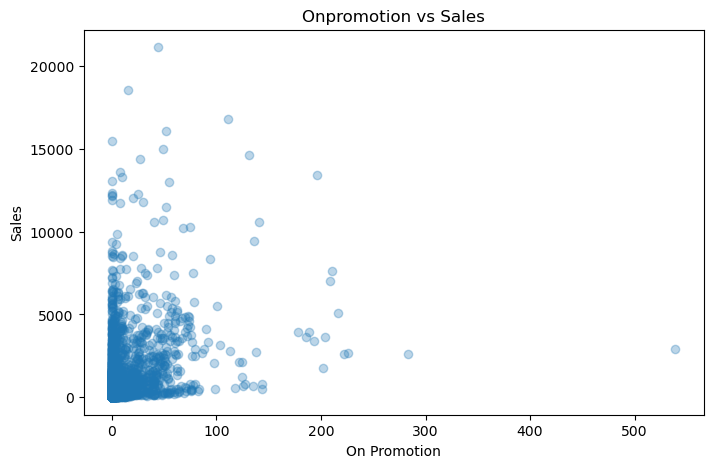

In [41]:
sample = train.sample(10000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample["onpromotion"], sample["sales"], alpha=0.3)
plt.xlabel("On Promotion")
plt.ylabel("Sales")
plt.title("Onpromotion vs Sales")
plt.show()

In [42]:
# polynomial features were not added because the onpromotion vs sales scatter plot does not show a clear, strong curved relationship

In [43]:
# adding polinomial terms without clear evidence could increase the model complexity and overfitting

In [44]:
train.isnull().sum().sort_values(ascending=False).head(10)

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
day_of_week     0
day_of_month    0
week_of_year    0
month           0
dtype: int64

In [45]:
train.dtypes

id                                    int64
date                         datetime64[ns]
store_nbr                             int64
family                               object
sales                               float64
onpromotion                           int64
day_of_week                           int32
day_of_month                          int32
week_of_year                          int64
month                                 int32
is_weekend                            int64
is_month_start                        int64
is_month_end                          int64
is_holiday                            int64
city                                 object
state                                object
type                                 object
cluster                               int64
store_frequency                     float64
family_frequency                    float64
store_family                         object
store_family_frequency              float64
holiday_weekday                 

In [46]:
# Remove temporary interaction text columns
train = train.drop(columns=["store_family", "holiday_weekday"])

print(train.shape)
print(train.columns.tolist())

(3000888, 22)
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday', 'city', 'state', 'type', 'cluster', 'store_frequency', 'family_frequency', 'store_family_frequency', 'holiday_weekday_frequency']


In [47]:
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

print("\nMissing values:")
print(train.isnull().sum().sum())

print("\nData types:")
print(train.dtypes)

Rows: 3000888
Columns: 22

Missing values:
0

Data types:
id                                    int64
date                         datetime64[ns]
store_nbr                             int64
family                               object
sales                               float64
onpromotion                           int64
day_of_week                           int32
day_of_month                          int32
week_of_year                          int64
month                                 int32
is_weekend                            int64
is_month_start                        int64
is_month_end                          int64
is_holiday                            int64
city                                 object
state                                object
type                                 object
cluster                               int64
store_frequency                     float64
family_frequency                    float64
store_family_frequency              float64
holiday_weekday_fr

In [48]:
engineered_features = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "store_frequency",
    "family_frequency",
    "store_family_frequency",
    "holiday_weekday_frequency"
]

train[engineered_features].head()

,day_of_week,day_of_month,week_of_year,month,is_weekend,is_month_start,is_month_end,is_holiday,store_frequency,family_frequency,store_family_frequency,holiday_weekday_frequency
0,1,1,1,1,0,1,0,1,0.018519,0.030303,0.000561,0.004751
1,1,1,1,1,0,1,0,1,0.018519,0.030303,0.000561,0.004751
2,1,1,1,1,0,1,0,1,0.018519,0.030303,0.000561,0.004751
3,1,1,1,1,0,1,0,1,0.018519,0.030303,0.000561,0.004751
4,1,1,1,1,0,1,0,1,0.018519,0.030303,0.000561,0.004751


In [50]:
# checking the holiday features

In [49]:
print("Holiday days:")
print(train["is_holiday"].value_counts())

print("\nPercentage of holiday rows:")
print(train["is_holiday"].mean() * 100)

Holiday days:
is_holiday
0    2911788
1      89100
Name: count, dtype: int64

Percentage of holiday rows:
2.9691211401425175


In [51]:
# checking the frequency encoding

In [52]:
print("Store frequency:")
print(train["store_frequency"].describe())

print("\nFamily frequency:")
print(train["family_frequency"].describe())

print("\nStore-family frequency:")
print(train["store_family_frequency"].describe())

Store frequency:
count    3.000888e+06
mean     1.851852e-02
std      2.439126e-13
min      1.851852e-02
25%      1.851852e-02
50%      1.851852e-02
75%      1.851852e-02
max      1.851852e-02
Name: store_frequency, dtype: float64

Family frequency:
count    3.000888e+06
mean     3.030303e-02
std      8.000789e-13
min      3.030303e-02
25%      3.030303e-02
50%      3.030303e-02
75%      3.030303e-02
max      3.030303e-02
Name: family_frequency, dtype: float64

Store-family frequency:
count    3.000888e+06
mean     5.611672e-04
std      4.005152e-14
min      5.611672e-04
25%      5.611672e-04
50%      5.611672e-04
75%      5.611672e-04
max      5.611672e-04
Name: store_family_frequency, dtype: float64


In [54]:
# polynomial features were not added to the final feature table. the scatter plot between onpromotion and ales showed highly 
# scatrterd relationship without clear quadractic pattern. adding polynomial terms without strong evidence  could unnecessarily increase model
# complexity and risk overfitting


In [55]:
feature_table_v1 = train.copy()

In [56]:
print(feature_table_v1.shape)

(3000888, 22)


In [57]:
feature_table_v1.to_parquet(
    "feature_table_v1.parquet",
    index=False
)

print("Feature table saved successfully!")

Feature table saved successfully!


In [58]:
feature_dictionary = pd.DataFrame({
    "Feature": [
        "id",
        "date",
        "store_nbr",
        "family",
        "sales",
        "onpromotion",
        "day_of_week",
        "day_of_month",
        "week_of_year",
        "month",
        "is_weekend",
        "is_month_start",
        "is_month_end",
        "is_holiday",
        "city",
        "state",
        "type",
        "cluster",
        "store_frequency",
        "family_frequency",
        "store_family_frequency",
        "holiday_weekday_frequency"
    ],
    
    "Description": [
        "Unique identifier for each observation",
        "Date of the sales observation",
        "Store identification number",
        "Product family/category",
        "Target variable representing sales",
        "Number of products on promotion",
        "Day of the week",
        "Day of the month",
        "Week number of the year",
        "Month number",
        "Indicates whether the date is Saturday or Sunday",
        "Indicates whether the date is the first day of the month",
        "Indicates whether the date is the last day of the month",
        "Indicates whether the date is an Ecuadorian public holiday",
        "City where the store is located",
        "State/province where the store is located",
        "Store type",
        "Store cluster",
        "Relative frequency of the store in the dataset",
        "Relative frequency of the product family in the dataset",
        "Relative frequency of the store-family combination",
        "Relative frequency of the holiday-weekday combination"
    ],
    
    "Source_Column": [
        "Original dataset",
        "Original dataset",
        "Original dataset",
        "Original dataset",
        "Original dataset",
        "Original dataset",
        "date",
        "date",
        "date",
        "date",
        "date",
        "date",
        "date",
        "date + Ecuador holiday calendar",
        "stores.csv",
        "stores.csv",
        "stores.csv",
        "stores.csv",
        "store_nbr",
        "family",
        "store_nbr + family",
        "is_holiday + day_of_week"
    ],
    
    "Encoding_Method": [
        "None",
        "Datetime",
        "Original categorical",
        "Original categorical",
        "Target",
        "Original numeric",
        "Date decomposition",
        "Date decomposition",
        "Date decomposition",
        "Date decomposition",
        "Binary flag",
        "Binary flag",
        "Binary flag",
        "Ecuador holidays package",
        "Original categorical",
        "Original categorical",
        "Original categorical",
        "Original numeric",
        "Frequency encoding",
        "Frequency encoding",
        "Interaction + frequency encoding",
        "Interaction + frequency encoding"
    ]
})

In [59]:
feature_dictionary

,Feature,Description,Source_Column,Encoding_Method
0,id,Unique identifier for each observation,Original dataset,None
1,date,Date of the sales observation,Original dataset,Datetime
2,store_nbr,Store identification number,Original dataset,Original categorical
3,family,Product family/category,Original dataset,Original categorical
4,sales,Target variable representing sales,Original dataset,Target
5,onpromotion,Number of products on promotion,Original dataset,Original numeric
6,day_of_week,Day of the week,date,Date decomposition
7,day_of_month,Day of the month,date,Date decomposition
8,week_of_year,Week number of the year,date,Date decomposition
9,month,Month number,date,Date decomposition


In [60]:
feature_dictionary.to_csv(
    "feature_dictionary.csv",
    index=False
)

print("Feature dictionary saved successfully!")

Feature dictionary saved successfully!


In [61]:
# now final verification


In [63]:
print("========== DAY 1 FINAL CHECK ==========")

print("\nFeature Table:")
print("Rows:", feature_table_v1.shape[0])
print("Columns:", feature_table_v1.shape[1])

print("\nMissing Values:")
print(feature_table_v1.isnull().sum().sum())

print("\nFiles created:")
print("1. feature_table_v1.parquet")
print("2. feature_dictionary.csv")

print("\nPolynomial Features:")
print("Not added — scatter plot did not show a clear nonlinear relationship.")


========== DAY 1 FINAL CHECK ==========

Feature Table:
Rows: 3000888
Columns: 22

Missing Values:
0

Files created:
1. feature_table_v1.parquet
2. feature_dictionary.csv

Polynomial Features:
Not added — scatter plot did not show a clear nonlinear relationship.
